In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../src")
# Geometry objectors
from hypo.lenspy import simple_Lens 
from hypo.surface import ConicSurface
from hypo.coordinate import coord_sys
# source objector
from hypo.Feedpy import GaussiBeam

# output objector
from hypo.field_storage import Spherical_grd,save_grd
from hypo.coxvec import Ludwig_Cox_vector as CO
from hypo.vecops import Vector, dot

In [2]:
'''1. Define coordinate system'''
coord_ref = coord_sys()


In [3]:
coord_feed = coord_sys(ref_coord = coord_ref)
coord_Lens1 = coord_sys(origin = [0,0,120], ref_coord= coord_ref)
coord_sky = coord_sys(origin = [0,0,.128], ref_coord =coord_ref)

In [4]:
'''2. Define lens two surfaces'''
radius_1 = 63 # mm
conic_const_1 = -2.325625
Lens_face1 = ConicSurface(radius_1, conic_const = conic_const_1)

radius_2 = np.inf 
Lens_face2 = ConicSurface(radius_2)

In [5]:
x = np.linspace(-25,25,100)
y = np.zeros(x.size)
z2 = Lens_face2.sag(x,y)
z1 = Lens_face1.sag(x,y)

In [6]:
'''3. Define Simple Lens'''
# refractive index
HDPE = 1.525
# thickness
t1 = 8 #mm
# diameter
D  = 50# mm

Lens1 = simple_Lens(HDPE,
                    t1,
                    D,
                    Lens_face1,
                    Lens_face2,
                    coord_Lens1,
                    name = 'Lens1',
                    AR_file = None,
                    outputfolder = 'Data/singleLens/')

In [7]:
'''4. Source: an idea Gaussian beam'''
Edge_taper  = -20 #dB
Edge_angle = 10 # degree
freq = 90
Feed = GaussiBeam(Edge_taper, Edge_angle, freq, coord_feed,polarization='x')

1.8862605197565134


In [8]:
'''5. Define the fields wanted to calculated'''

Beammap = Spherical_grd(coord_ref,
                        0,0,80,80,
                        1001,1001,
                        Type = 'eloveraz',
                        far_near = 'far' )

In [9]:
''' Start PO anlaysis'''

Lens1.PO_analysis(Feed,
                  [42,128],
                  [48,77],
                  freq)
Lens1.source(Beammap, freq, far_near = 'far')
save_grd(Beammap, 'Data/singleLens/centerbeam.h5')

None 90GHz
Batch size: 32
Batch size: 32


100%|██████████| 79/79 [00:00<00:00, 189.44it/s]


Batch size: 32


100%|██████████| 31312/31312 [00:20<00:00, 1503.43it/s]


In [10]:
r, theta, phi = Beammap.coord_sys.ToSpherical(Beammap.grid.x,Beammap.grid.y, Beammap.grid.z)
co,cx,crho = CO(theta,phi)
print(co)
E_co = dot(Beammap.E , co)
E_cx = dot(Beammap.E , cx)

Vector(numpy, shape=(3, 1002001))


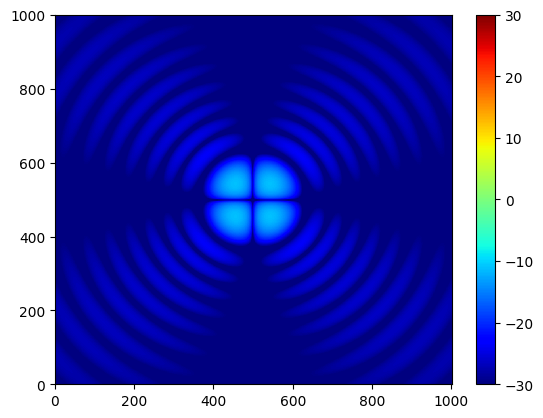

In [11]:
plt.pcolor(np.log10(np.abs(Beammap.E.y.reshape(1001,-1)))*10,cmap = 'jet',vmax = 30,vmin = -30)
plt.colorbar()

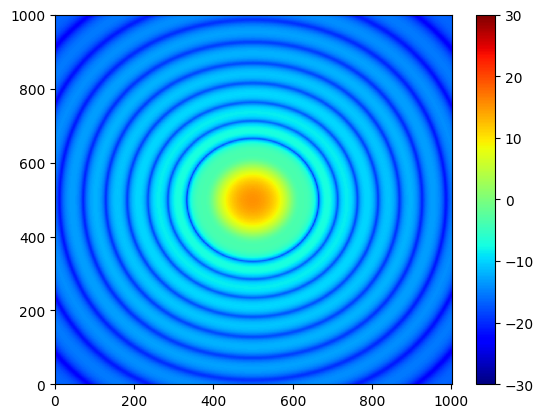

In [12]:
plt.pcolor(np.log10(np.abs(Beammap.E.x.reshape(1001,-1)))*10,cmap = 'jet',vmax = 30,vmin = -30)
plt.colorbar()